In [1]:
!pip install scikit-image


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# Basic operating system (os), numerical, and plotting functionality
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

# scipy statistics functions
from scipy.stats import mode
from scipy.stats import moment

# scikit-learn data utilities
from sklearn.datasets import make_blobs
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# Color transformations
from skimage.color import rgb2lab

# Feature extractors and classification algorithm
from skimage.feature import graycomatrix, graycoprops
from skimage.feature import local_binary_pattern
from sklearn.cluster import KMeans

# scikit-learn performance metric utilities
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import completeness_score

In [3]:
# Set plotting preferences
import matplotlib
%matplotlib inline
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 16}
matplotlib.rc('font', **font)

In [5]:
import pickle

file_path = "/work/dataset/OriginalDataset"

In [6]:
#DATASET 1

import os

# Specify the path to the "OriginalDataset" directory
dataset_directory = "/work/dataset/OriginalDataset"

# List the subfolders (Alzheimer classifications)
alzheimer_classifications = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Initialize a dictionary to store counts for each classification
classification_counts = {}

# Iterate through each classification folder and count the files
for classification in alzheimer_classifications:
    classification_path = os.path.join(dataset_directory, classification)
    num_samples = len(os.listdir(classification_path))
    classification_counts[classification] = num_samples

# Total number of data pieces
total_samples = sum(classification_counts.values())

# Print the counts for each classification and the total count
for classification, count in classification_counts.items():
    print(f"{classification}: {count} samples")
print(f"Total: {total_samples} samples")


MildDemented: 896 samples
ModerateDemented: 64 samples
NonDemented: 3200 samples
VeryMildDemented: 2240 samples
Total: 6400 samples


In [ ]:
from PIL import Image
import os
import numpy as np

# Path to the directory containing JPG images
dataset_dir = '/work/dataset/OriginalDataset'

# List of subfolders (Alzheimer classifications)
alzheimer_classifications = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Initialize lists to store images and corresponding labels
images = []
labels = []

# Load images and labels
for classification in alzheimer_classifications:
    classification_dir = os.path.join(dataset_dir, classification)
    
    for image_name in os.listdir(classification_dir):
        if image_name.lower().endswith(('.jpg', '.jpeg')):
            image_path = os.path.join(classification_dir, image_name)
            image = Image.open(image_path)
            # Resize, convert to grayscale, and normalize the image
            image = image.resize((128, 128))
            image = image.convert("L")
            image_array = np.array(image) / 255.0
            images.append(image_array)
            labels.append(classification)

# Convert the lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Convert string labels to integers
label_mapping = {label: idx for idx, label in enumerate(np.unique(labels))}
labels = np.array([label_mapping[label] for label in labels], dtype=np.int32)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)


In [8]:
import numpy as np
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split

# Split  into training, validation, and test
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Another split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Print the shape of the data for verification
print("Training Images shape:", X_train.shape)
print("Training Labels shape:", y_train.shape)
print("Validation Images shape:", X_val.shape)
print("Validation Labels shape:", y_val.shape)
print("Test Images shape:", X_test.shape)
print("Test Labels shape:", y_test.shape)


2023-10-24 17:38:14.615419: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-24 17:38:14.786341: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-10-24 17:38:14.786396: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-10-24 17:38:14.832371: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-10-24 17:38:16.758091: W tensorflow/stream_executor/platform/de

In [9]:
# Define the CNN architecture
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128,128,1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(labels)), activation='softmax'))

# Compile
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


2023-10-24 17:38:19.607613: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2023-10-24 17:38:19.607674: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2023-10-24 17:38:19.607709: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (p-3231e16a-8115-4093-b951-50dcb9c846b3): /proc/driver/nvidia/version does not exist
2023-10-24 17:38:19.608218: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
X_train.shape

(4096, 128, 128)

In [11]:
X_test.shape

(1280, 128, 128)

In [12]:
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))


Epoch 1/10
128/128 [==============================] - 190s 1s/step - loss: 1.0264 - accuracy: 0.5105 - val_loss: 0.8714 - val_accuracy: 0.6133
Epoch 2/10
128/128 [==============================] - 188s 1s/step - loss: 0.8138 - accuracy: 0.6372 - val_loss: 0.6466 - val_accuracy: 0.7480
Epoch 3/10
128/128 [==============================] - 190s 1s/step - loss: 0.5294 - accuracy: 0.7861 - val_loss: 0.3869 - val_accuracy: 0.8623
Epoch 4/10
128/128 [==============================] - 189s 1s/step - loss: 0.2608 - accuracy: 0.9119 - val_loss: 0.2402 - val_accuracy: 0.9219
Epoch 5/10
128/128 [==============================] - 190s 1s/step - loss: 0.1151 - accuracy: 0.9646 - val_loss: 0.1734 - val_accuracy: 0.9473
Epoch 6/10
128/128 [==============================] - 193s 2s/step - loss: 0.0435 - accuracy: 0.9910 - val_loss: 0.1359 - val_accuracy: 0.9609
Epoch 7/10
128/128 [==============================] - 195s 2s/step - loss: 0.0175 - accuracy: 0.9985 - val_loss: 0.1227 - val_accuracy: 0.9639

In [13]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator
from keras.applications.mobilenet import preprocess_input
from keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [14]:
print("Training Images shape:", X_train.shape)
print("Training Labels shape:", y_train.shape)
print("Validation Images shape:", X_val.shape)
print("Validation Labels shape:", y_val.shape)
print("Test Images shape:", X_test.shape)
print("Test Labels shape:", y_test.shape)


Training Images shape: (4096, 128, 128)
Training Labels shape: (4096,)
Validation Images shape: (1024, 128, 128)
Validation Labels shape: (1024,)
Test Images shape: (1280, 128, 128)
Test Labels shape: (1280,)


In [15]:
from keras.preprocessing.image import ImageDataGenerator

# Define the paths to the dataset and subfolders
dataset_dir = '/work/dataset/OriginalDataset'
class_subfolders = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Define parameters for data loading and preprocessing
batch_size = 32
image_size = (224, 224)  # Adjust the size to fit ResNet50 input requirements

# Create an ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values
    validation_split=0.2,  # Split data into training and validation sets
)

# Load and preprocess images from subfolders
train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=class_subfolders,
    subset='training',  # Use 'training' for the training set
)

validation_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=class_subfolders,
    subset='validation',  # Use 'validation' for the validation set
)


Found 5121 images belonging to 4 classes.
Found 1279 images belonging to 4 classes.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input  # Correct import
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load ResNet-50 model (include_top=False if you don't need the fully connected layers)
model = ResNet50(weights='imagenet')

# Specify the base directory where your data is stored
base_directory = '/work/dataset/OriginalDataset'

# List of subfolders (categories)
categories = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

# Initialize an empty list to store the image predictions
all_predictions = []

# Define the target input size for ResNet-50
target_size = (224, 224)

# Iterate through each category and load images
for category in categories:
    category_directory = os.path.join(base_directory, category)
    for image_name in os.listdir(category_directory):
        if image_name.lower().endswith(('.jpg', '.jpeg')):
            image_path = os.path.join(category_directory, image_name)
            
            # Load and preprocess the image
            image = load_img(image_path, target_size=target_size)
            image = img_to_array(image)
            image = preprocess_input(image)
            image = np.expand_dims(image, axis=0)
            
            # Predict using the model
            predictions = model.predict(image)
            
            # Append the predictions to the list
            all_predictions.append(predictions)

# Now, all_predictions contains the model predictions for all the images


1/1 [==============================] - ETA: 0s

ImportError: libGL.so.1: cannot open shared object file: No such file or directory

In [ ]:
from keras.applications import MobileNetV2
from keras.layers import GlobalAveragePooling2D, Dense
from keras.models import Model

# Define the pre-trained MobileNetV2 model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 1))

# Add your custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)  # Add more dense layers as needed
predictions = Dense(4, activation='softmax')(x)  # Replace '4' with the actual number of classes

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)


ValueError: The input must have 3 channels; Received `input_shape=(128, 128, 1)`

In [ ]:
# Print the shape of the data for verification
print("Training Images shape:", X_train.shape)
print("Training Labels shape:", y_train.shape)
print("Validation Images shape:", X_val.shape)
print("Validation Labels shape:", y_val.shape)
print("Test Images shape:", X_test.shape)
print("Test Labels shape:", y_test.shape)


Training Images shape: (4096, 128, 128)
Training Labels shape: (4096,)
Validation Images shape: (1024, 128, 128)
Validation Labels shape: (1024,)
Test Images shape: (1280, 128, 128)
Test Labels shape: (1280,)


In [ ]:
from keras.utils import to_categorical

# Ensure y_train, y_val, and y_test are 1D arrays
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

# Perform one-hot encoding
num_classes = 4  # Assuming you have 4 classes
y_train = to_categorical(y_train, num_classes)
y_val = to_categorical(y_val, num_classes)
y_test = to_categorical(y_test, num_classes)


In [ ]:
# Print the shape of the data for verification
print("Training Images shape:", X_train.shape)
print("Training Labels shape:", y_train.shape)
print("Validation Images shape:", X_val.shape)
print("Validation Labels shape:", y_val.shape)
print("Test Images shape:", X_test.shape)
print("Test Labels shape:", y_test.shape)


Training Images shape: (4096, 128, 128)
Training Labels shape: (4096, 4)
Validation Images shape: (1024, 128, 128)
Validation Labels shape: (1024, 4)
Test Images shape: (1280, 128, 128)
Test Labels shape: (1280, 4)


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (4096, 128, 128)
y_train shape: (4096, 4)
X_val shape: (1024, 128, 128)
y_val shape: (1024, 4)
X_test shape: (1280, 128, 128)
y_test shape: (1280, 4)


In [ ]:
X_train = X_train.reshape(-1, 128, 128, 1)
X_val = X_val.reshape(-1, 128, 128, 1)
X_test = X_test.reshape(-1, 128, 128, 1)


In [ ]:
# Freeze the layers of the base MobileNet model
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(lr=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Preprocess and augment the data
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Train the model
model.fit(datagen.flow(X_train, y_train, batch_size=32), validation_data=(X_val, y_val), epochs=10)

# Evaluate the model on the test data
accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy[1]:.2f}")

Epoch 1/10


InvalidArgumentError: Graph execution error:

Detected at node 'model/conv1_relu/Relu6' defined at (most recent call last):
    File "/usr/local/lib/python3.9/runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/usr/local/lib/python3.9/runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "/shared-libs/python3.9/py-core/lib/python3.9/site-packages/ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "/shared-libs/python3.9/py-core/lib/python3.9/site-packages/traitlets/config/application.py", line 982, in launch_instance
      app.start()
    File "/shared-libs/python3.9/py-core/lib/python3.9/site-packages/ipykernel/kernelapp.py", line 712, in start
      self.io_loop.start()
    File "/shared-libs/python3.9/py-core/lib/python3.9/site-packages/tornado/platform/asyncio.py", line 215, in start
      self.asyncio_loop.run_forever()
    File "/usr/local/lib/python3.9/asyncio/base_events.py"

In [ ]:
# Average the predictions from both models
combined_predictions = (cnn_predictions + mobilenet_predictions) / 2


In [ ]:
# Evaluate the ensemble model
ensemble_loss, ensemble_accuracy = ensemble_model.evaluate(X_test, y_test)
print(f"Ensemble Model Accuracy: {ensemble_accuracy:.2f}")


In [ ]:
scores = model.evaluate(X_val,y_val,verbose = 0)
print('\nTesting model on test set:')
print(f'Model Loss: {scores[0]:.3f}, Validation Accuracy: {scores[1]:.3f}')


Testing model on test set:
Model Loss: 0.134, Validation Accuracy: 0.969


In [ ]:
scores = model.evaluate(X_test, y_test, verbose=0)

print('\nTesting model on test set:')
print(f'Model Loss: {scores[0]:.3f}, Test Accuracy: {scores[1]:.3f}')


Testing model on test set:
Model Loss: 0.126, Test Accuracy: 0.973


32/32 [==============================] - 3s 78ms/step
Confusion Matrix:
[[128   0   2   8]
 [  0   6   0   2]
 [  3   0 516   5]
 [  1   0  11 342]]


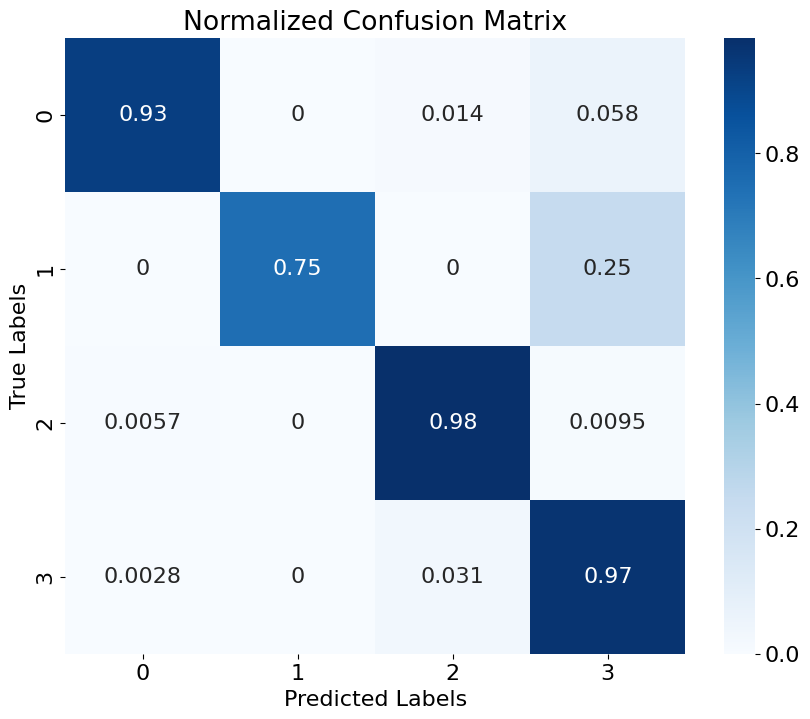

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the model predictions for the validation set
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

# Create the confusion matrix
cm = confusion_matrix(y_val, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Calculate the row-wise sum of the confusion matrix
row_sums = cm.sum(axis=1, keepdims=True)

# Create the normalized confusion matrix
normalized_cm = cm / row_sums

# Visualize the normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(normalized_cm, annot=True, cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Normalized Confusion Matrix')
plt.show()


In [ ]:
# Create the classification report
target_names = list(label_mapping.keys())
report = classification_report(y_val, y_pred_classes, target_names=target_names)
print("Classification Report:")
print(report)


Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.97      0.93      0.95       138
ModerateDemented       1.00      0.75      0.86         8
     NonDemented       0.98      0.98      0.98       524
VeryMildDemented       0.96      0.97      0.96       354

        accuracy                           0.97      1024
       macro avg       0.98      0.91      0.94      1024
    weighted avg       0.97      0.97      0.97      1024



In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score


40/40 [==============================] - 3s 82ms/step


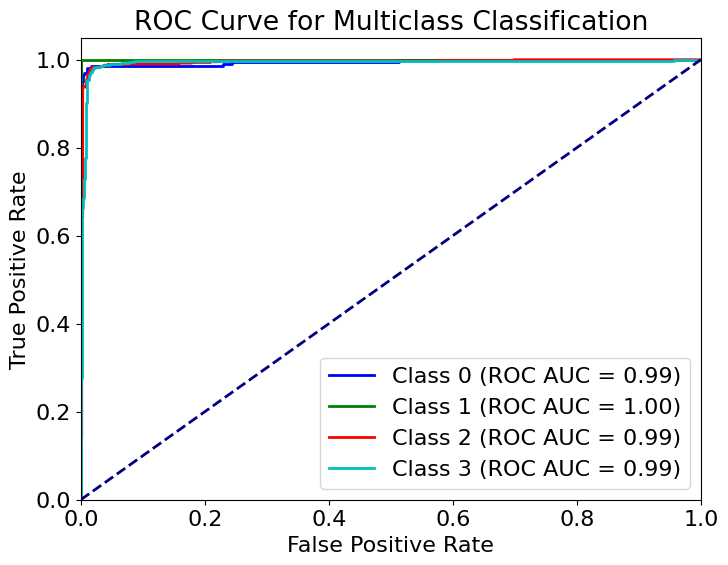

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Predict probabilities on the test data
y_pred_prob = model.predict(X_test)

# Binarize the labels
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

# Initialize lists to store fpr, tpr, and roc_auc for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate ROC curve and ROC AUC for each class
for i in range(len(np.unique(labels))):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(8, 6))
colors = ['b', 'g', 'r', 'c']  # You can add more colors as needed
for i in range(len(np.unique(labels))):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, label=f'Class {i} (ROC AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multiclass Classification')
plt.legend(loc="lower right")
plt.show()
